# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'NEE'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.083 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Using data from 2024-08-22 00:00:00 to 2025-06-05 00:00:00

Target column: NEE_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.468070,0.0,0.000,11.276667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0
2024-08-22 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,3.661990,0.0,0.000,11.043333,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1
2024-08-22 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,uncertain,1.0,0.965964,0.0,0.000,10.890000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2
2024-08-22 01:45:00,6.566236,NaN,NaN,6.566236,NaN,NaN,A,certain,0.0,1.585380,0.0,0.000,10.720000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3
2024-08-22 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,1.852140,0.0,0.000,10.820000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,10.578562,10.578562,10.578562,10.578562,10.578562,B,certain,1.0,0.510651,0.0,0.017,15.693333,0.0,0.0,...,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,13771
2025-06-04 22:15:00,9.416519,9.416519,9.416519,9.416519,9.416519,9.416519,B,certain,1.0,0.432552,0.0,0.034,15.516667,0.0,0.0,...,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,39.111514,13772
2025-06-04 22:45:00,10.095010,10.095010,10.095010,10.095010,10.095010,10.095010,B,certain,1.0,0.580992,0.0,0.425,15.660000,0.0,0.0,...,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,39.143246,13773


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 5667/6490 rows kept


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 07:15:00,0.458310,0.458310,0.458310,0.458310,0.458310,0.458310,A,certain,0.0,1.285700,431.104,0.000,12.856667,463.455774,238.485483,...,NaN,-0.682222,NaN,NaN,-0.775808,NaN,NaN,-0.106238,NaN,NaN,-0.140377,NaN,NaN,0.000000,14
2024-08-22 07:45:00,1.732697,1.732697,1.732697,1.732697,1.732697,1.732697,A,certain,0.0,0.693051,541.111,0.000,13.773333,597.920344,295.756936,...,NaN,-0.714815,NaN,NaN,-0.669836,NaN,NaN,-0.114511,NaN,NaN,-0.125648,NaN,NaN,0.000000,15
2024-08-22 08:15:00,3.723730,3.723730,3.723730,3.723730,3.723730,3.723730,A,certain,0.0,1.156790,645.302,0.017,14.390000,748.525831,364.338663,...,NaN,-0.713703,NaN,NaN,-0.571430,NaN,NaN,-0.217084,NaN,NaN,-0.076103,NaN,NaN,0.000000,16
2024-08-22 14:15:00,7.585572,7.585572,7.585572,7.585572,7.585572,7.585572,A,certain,0.0,0.692173,970.377,0.000,22.596667,1307.837924,646.809543,...,NaN,-0.131111,-0.844814,NaN,-0.732193,-1.303623,NaN,-0.603830,-0.820914,NaN,-0.181685,-0.257788,NaN,0.000000,28
2024-08-22 14:45:00,7.660107,7.660107,7.660107,7.660107,7.660107,7.660107,A,certain,0.0,3.552050,905.835,0.000,23.103333,1492.280787,744.993580,...,NaN,-0.080370,-0.762221,NaN,-0.974437,-1.441244,NaN,-0.601154,-0.871593,NaN,-0.217355,-0.290252,NaN,0.000000,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 20:45:00,10.168117,10.168117,10.168117,10.168117,10.168117,10.168117,B,certain,1.0,0.475160,0.000,0.017,15.886667,0.000000,0.000000,...,-0.993889,0.300000,0.300000,-0.201111,-0.193212,-0.844622,-1.290895,-0.200862,-0.530309,-0.928129,-0.159913,-0.976200,-1.424850,39.016319,13769
2025-06-04 21:15:00,10.359786,10.359786,10.359786,10.359786,10.359786,10.359786,B,certain,1.0,0.448754,0.000,0.017,15.786667,0.000000,0.000000,...,-0.947778,0.284444,0.305001,-0.229445,-0.121255,-0.853115,-1.277483,-0.177867,-0.529632,-0.893077,-0.144427,-0.967252,-1.448612,39.048051,13770
2025-06-04 21:45:00,10.578562,10.578562,10.578562,10.578562,10.578562,10.578562,B,certain,1.0,0.510651,0.000,0.017,15.693333,0.000000,0.000000,...,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,13771


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set



Training rows (complete-case): 5664/5667


,SW_IN_POT,ppfd,sw_in,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.3_gfXG,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert,ts_0.05_gfXG_lag9h,...,ts_0.15_gfXG_lag3h_roll6hmean,ts_0.15_gfXG_lag9h_roll9hmean,ts_0.3_gfXG_lag3h_roll6hmean,ts_0.3_gfXG_lag6h_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,ts_0.3_gfXG_lag9h_roll3hmean,ts_0.3_gfXG_lag9h_roll6hmean,ts_0.3_gfXG_lag9h_roll9hmean,wfps_0.3_gfXG_lag3h_roll9hmean,wfps_0.3_gfXG_lag6h_roll9hmean,wfps_0.3_gfXG_lag9h_roll6hmean,wfps_0.3_gfXG_lag9h_roll9hmean,id,trt,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 14:15:00,970.377,1307.837924,646.809543,20.075556,19.077037,42.204569,187.253968,187.385430,185.092799,0.048881,1.0,60.0,60.0,1.0,16.702593,...,18.560031,19.670842,19.227284,19.371605,19.694640,19.734506,19.870841,19.870841,42.417419,42.444845,42.474414,42.474414,28,0.0,7.585572
2024-08-22 14:45:00,905.835,1492.280787,744.993580,20.372222,19.119630,42.169136,187.067460,187.379274,184.373050,0.120233,1.0,60.0,60.0,1.0,16.569630,...,18.549660,19.607130,19.183271,19.316913,19.667160,19.675555,19.842284,19.842284,42.412748,42.441603,42.467107,42.467107,29,0.0,7.660107
2024-08-22 15:15:00,829.238,1470.588387,744.041813,20.632593,19.200000,42.136662,186.880952,187.373056,183.656100,0.247123,1.0,60.0,60.0,1.0,16.479630,...,18.563951,19.545214,19.145617,19.266111,19.613148,19.615555,19.786666,19.812250,42.406318,42.434090,42.455569,42.462379,30,1.0,12.252563
2024-08-22 15:45:00,741.895,1322.432487,671.122436,20.870000,19.238148,42.112901,186.694444,187.366777,182.941939,0.447626,1.0,60.0,60.0,1.0,16.454441,...,18.603055,19.484841,19.112284,19.216111,19.558004,19.553642,19.728950,19.782804,42.398034,42.430063,42.443464,42.456491,31,1.0,8.197114
2024-08-22 16:45:00,541.111,889.933601,471.120883,21.298518,19.402963,42.066197,186.321429,187.354029,181.521936,1.135164,1.0,60.0,60.0,1.0,16.544075,...,18.776944,19.370486,19.058827,19.117654,19.447572,19.437098,19.612530,19.725046,42.378535,42.420140,42.421296,42.448507,33,1.0,6.387116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 20:45:00,0.000,0.000000,0.000000,18.723889,17.300000,45.234460,0.000000,0.000000,0.000000,0.000000,60.0,23.0,60.0,30.0,20.283334,...,18.722824,17.924599,17.041018,16.952037,16.994444,16.937407,17.015648,17.107500,45.643325,45.955291,46.151749,46.237744,13769,1.0,10.168117
2025-06-04 21:15:00,0.000,0.000000,0.000000,18.675556,17.300000,45.197942,0.000000,0.000000,0.000000,0.000000,60.0,23.0,60.0,30.0,20.996111,...,18.801574,17.910710,17.066111,16.971296,16.984228,16.921574,16.990694,17.079784,45.619181,45.899785,46.103465,46.198731,13770,1.0,10.359786
2025-06-04 21:45:00,0.000,0.000000,0.000000,18.566111,17.300000,45.159003,0.000000,0.000000,0.000000,0.000000,60.0,23.0,60.0,30.0,21.566665,...,18.861806,17.909198,17.095741,17.003518,16.980679,16.908241,16.969259,17.054537,45.588312,45.841329,46.047620,46.153584,13771,1.0,10.578562


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: fitted mixture (cvm distance 1.8083; raw baseline 16.4885)


CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.098-0.102
  Coverage: 1988/5664 rows never held out (35.1%); mean times held out 1.00


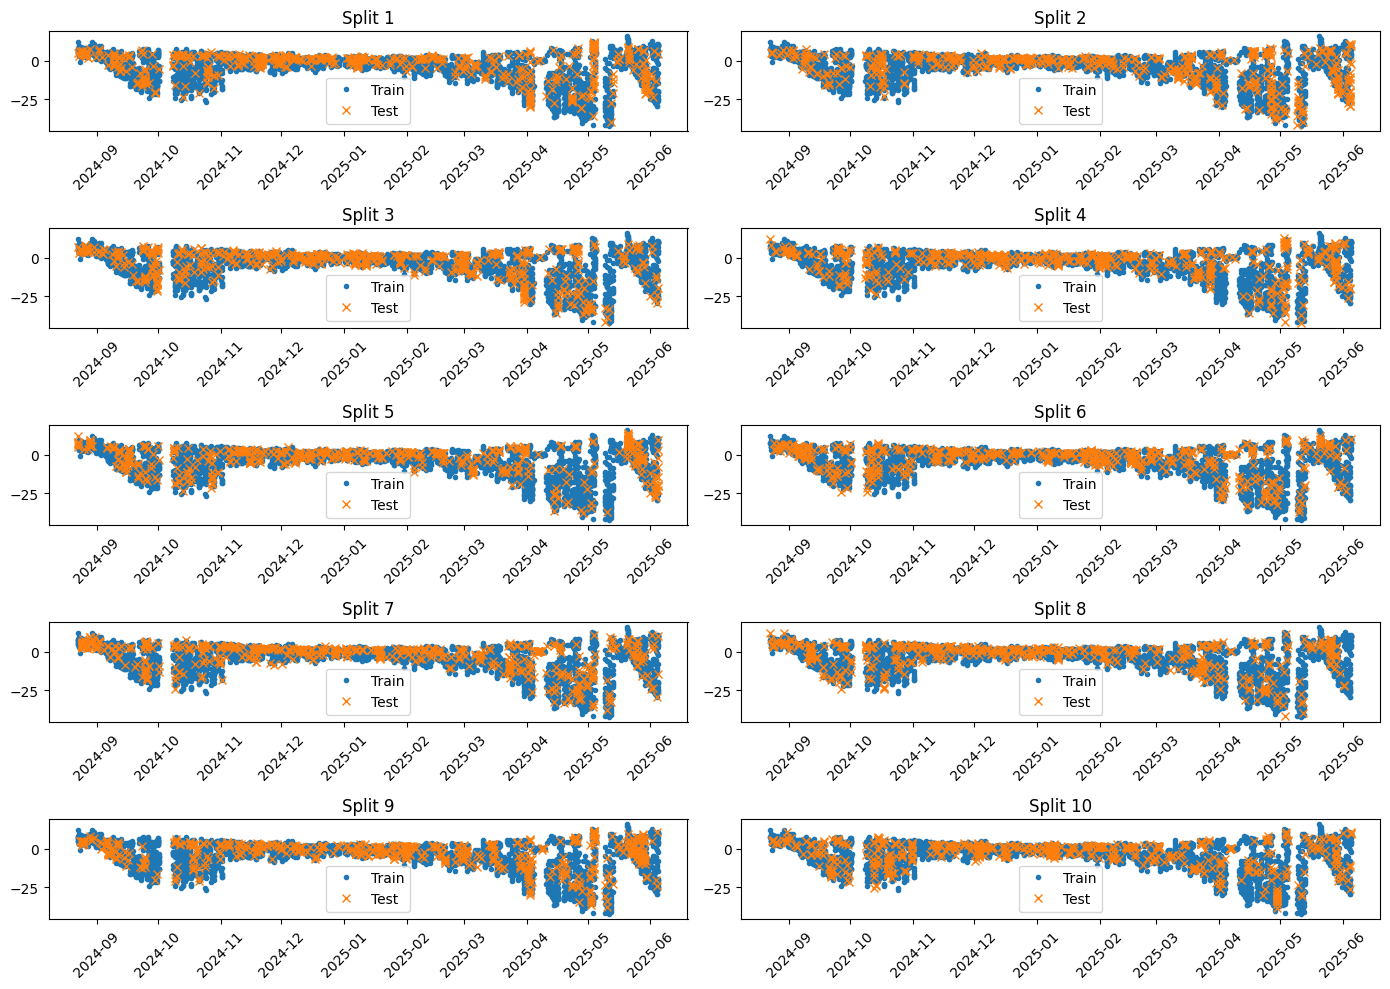

In [8]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=splits,       # list of (train_idx, test_idx) 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits


Best RMSE: 1.6828
Best Params: {'colsample_bytree': np.float64(0.8783251227163527), 'gamma': np.float64(0.4291794024068599), 'learning_rate': np.float64(0.037595890520188475), 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 445, 'subsample': np.float64(0.8048372233197124)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-10-06 16:11:45
